In [76]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from utils import *

num_bins = 4 # Cosmic shear part

In [77]:
# Load Cosmolike data
mystery_factor = 1.01104325067
theta = get_theta(2.5/mystery_factor, 995.2679263837432/mystery_factor, 26)
_, dv_cosmolike   = np.loadtxt("../cosmolike/LCDM.modelvector", unpack=True)

In [78]:
# Load Cosmosis data
COSMOSIS_DATA_PATH = "../cosmosis/lcdm_datavector_run/"
dv_cosmosis = []
theta_cosmosis = np.loadtxt(f"{COSMOSIS_DATA_PATH}/shear_xi_plus/theta.txt")*RAD_TO_ARCMIN
theta_edges_cosmosis = np.loadtxt(f"{COSMOSIS_DATA_PATH}/shear_xi_plus/theta_edges.txt")*RAD_TO_ARCMIN
for corr_func in ["plus", "minus"]:
    for i in range(1, num_bins + 1):
        for j in range(i, num_bins + 1):
            xi_ij = np.loadtxt(f"{COSMOSIS_DATA_PATH}/shear_xi_{corr_func}/bin_{j}_{i}.txt")
            # xi_ij = xi_ij[theta_cosmosis < 250]
            dv_cosmosis.append(xi_ij)
dv_cosmosis = np.array(dv_cosmosis).flatten()

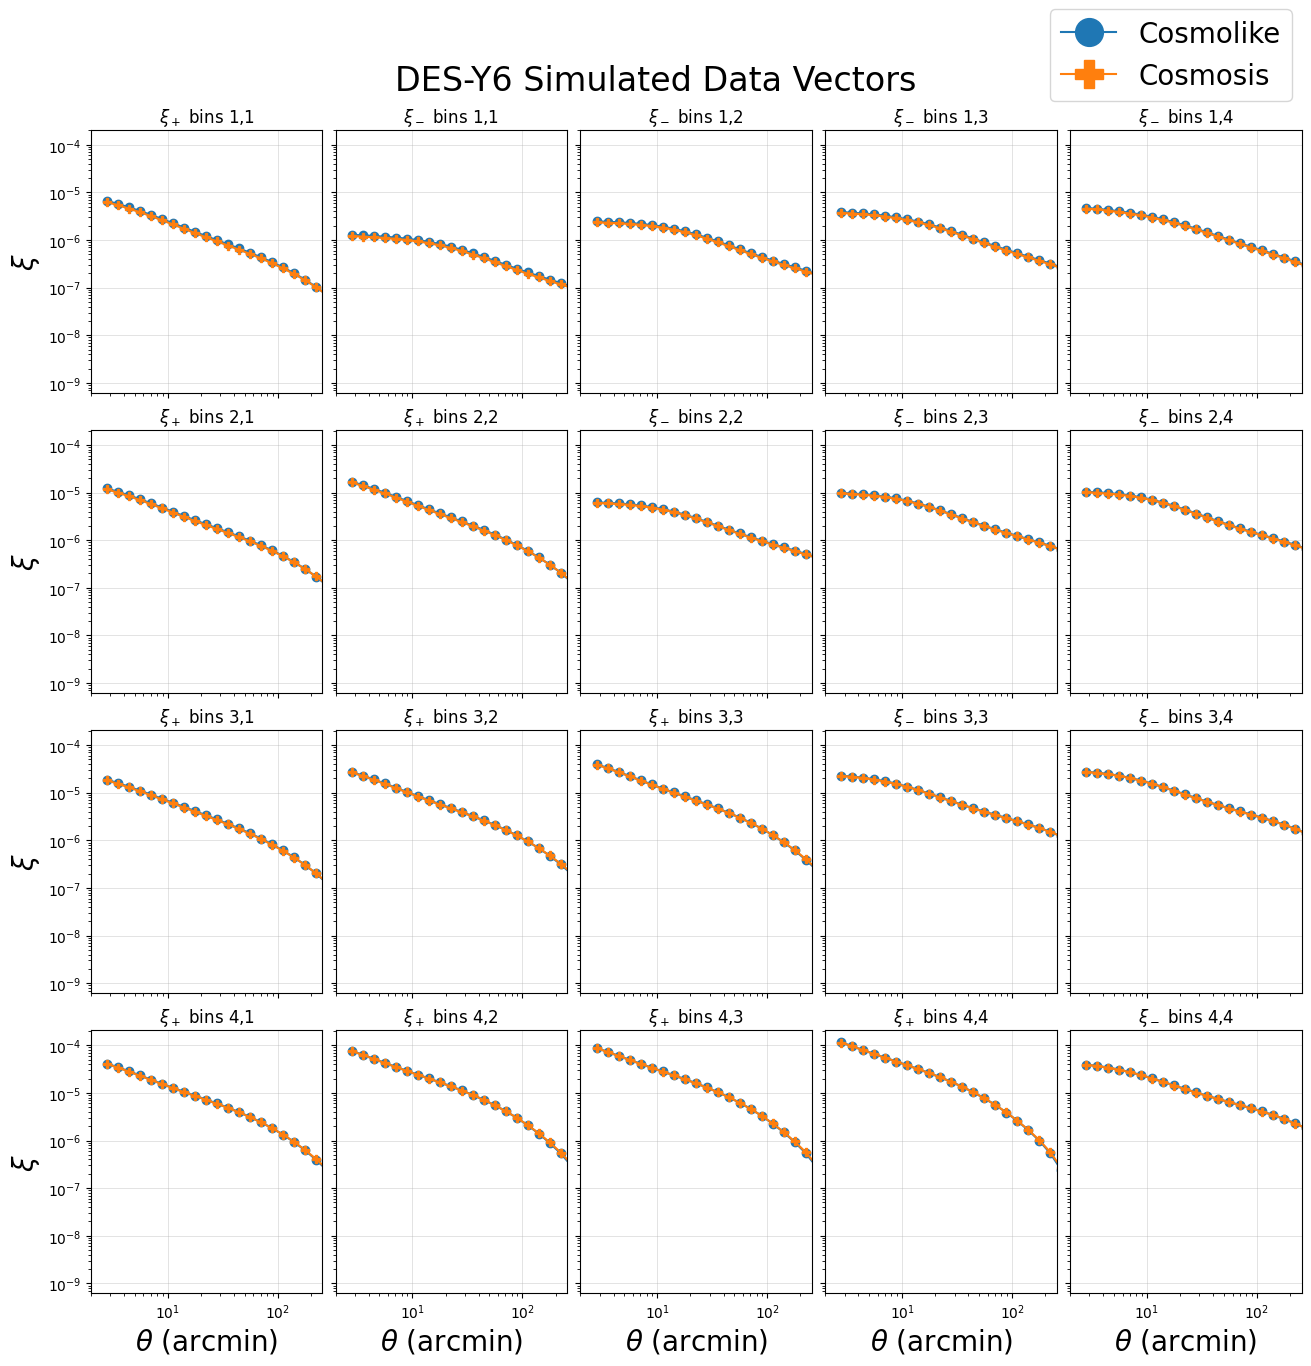

In [79]:
num_bins = 4
num_cols = num_bins+1
block_size = len(theta)
tri_count = num_bins * (num_bins + 1) // 2

xi_plus_cosmolike  = dv_cosmolike[:tri_count * block_size]
xi_minus_cosmolike = dv_cosmolike[tri_count * block_size:2 * tri_count * block_size]
xi_plus_cosmosis  = dv_cosmosis[:tri_count * block_size]
xi_minus_cosmosis = dv_cosmosis[tri_count * block_size:2 * tri_count * block_size]

fig, axes = plt.subplots(num_bins, num_cols, figsize=(13, 13), sharex=True, sharey=True, constrained_layout=True)
plus_idx = 0
minus_idx = 0

for i in range(num_bins):
    for col in range(num_cols):
        ax = axes[i, col]

        if col <= i:
            j = col
            start = plus_idx * block_size
            end = start + block_size
            ax.loglog(theta, xi_plus_cosmolike[start:end], color='C0', marker='o', linestyle='-')
            ax.loglog(theta, xi_plus_cosmosis[start:end], color='C1', marker='P', linestyle='-')
            line_idx = plus_idx
            plus_idx += 1
            label = r'$\xi_+$'
        else:
            j = col - 1
            start = minus_idx * block_size
            end = start + block_size
            ax.loglog(theta, xi_minus_cosmolike[start:end], color='C0', marker='o', linestyle='-')
            ax.loglog(theta, xi_minus_cosmosis[start:end], color='C1', marker='P', linestyle='-')
            line_idx = tri_count + minus_idx
            minus_idx += 1
            label = r'$\xi_-$'

        if i == num_bins - 1:
            ax.set_xlabel('$\\theta$ (arcmin)', fontsize=20)
        if col == 0:
            ax.set_ylabel('$\\xi$', fontsize=20)

        ax.set_title(f'{label} bins {i+1},{j+1}', fontsize=12)
        ax.set_xlim([2, 255])
        ax.grid(True, linewidth=0.5, alpha=0.5)

handles = [
    Line2D([], [], marker="o", color="C0", markersize=20, label="Cosmolike"),
    Line2D([], [], marker="P", color="C1", markersize=20, label="Cosmosis"),
]
fig.legend(handles=handles, bbox_to_anchor=(1, 1.05), fontsize=20)

fig.suptitle('DES-Y6 Simulated Data Vectors', fontsize=24)
plt.savefig("comparison_shear.pdf", bbox_inches="tight")
plt.show()

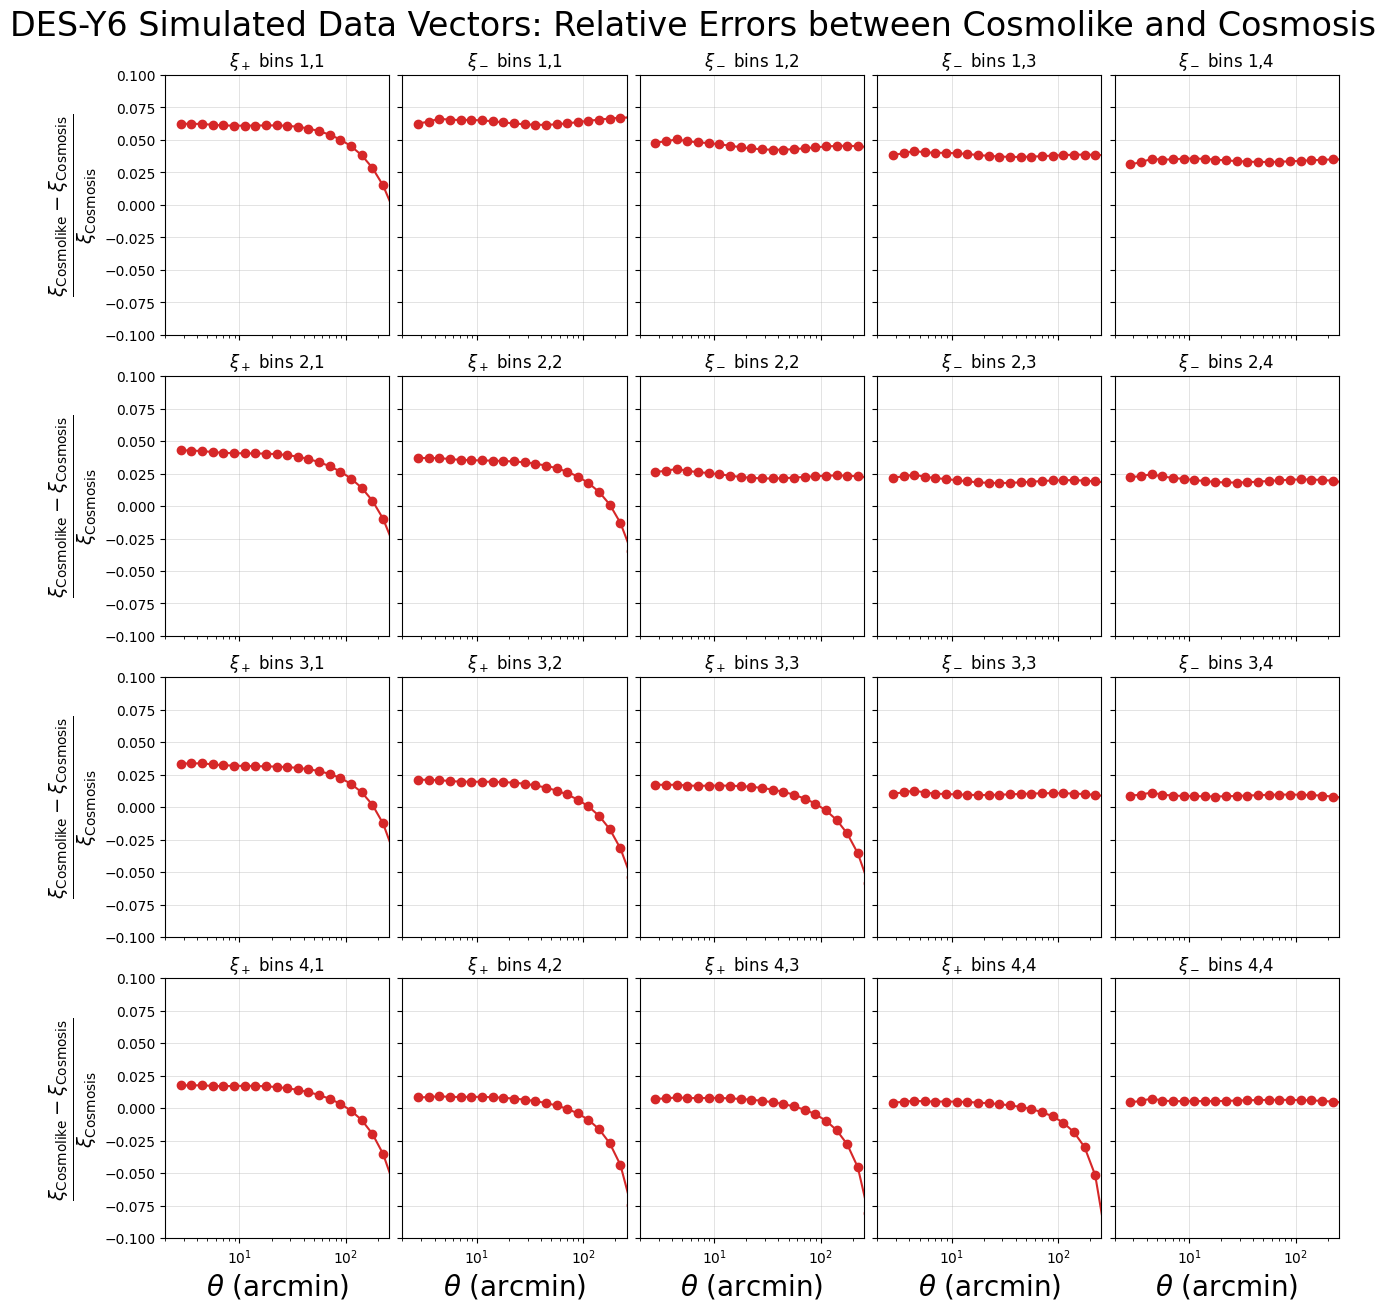

In [80]:
num_bins = 4
num_cols = num_bins+1
block_size = len(theta)
tri_count = num_bins * (num_bins + 1) // 2

xi_plus_cosmolike  = dv_cosmolike[:tri_count * block_size]
xi_minus_cosmolike = dv_cosmolike[tri_count * block_size:2 * tri_count * block_size]
xi_plus_cosmosis  = dv_cosmosis[:tri_count * block_size]
xi_minus_cosmosis = dv_cosmosis[tri_count * block_size:2 * tri_count * block_size]

fig, axes = plt.subplots(num_bins, num_cols, figsize=(13, 13), sharex=True, sharey=True, constrained_layout=True)
plus_idx = 0
minus_idx = 0

for i in range(num_bins):
    for col in range(num_cols):
        ax = axes[i, col]

        if col <= i:
            j = col
            start = plus_idx * block_size
            end = start + block_size
            rel_error = (xi_plus_cosmolike[start:end] - xi_plus_cosmosis[start:end])/xi_plus_cosmosis[start:end]
            ax.semilogx(theta, rel_error, color='C3', marker='o', linestyle='-')
            line_idx = plus_idx
            plus_idx += 1
            label = r'$\xi_+$'
        else:
            j = col - 1
            start = minus_idx * block_size
            end = start + block_size
            rel_error = (xi_minus_cosmolike[start:end] - xi_minus_cosmosis[start:end])/xi_minus_cosmosis[start:end]
            ax.semilogx(theta, rel_error, color='C3', marker='o', linestyle='-')
            line_idx = tri_count + minus_idx
            minus_idx += 1
            label = r'$\xi_-$'

        if i == num_bins - 1:
            ax.set_xlabel('$\\theta$ (arcmin)', fontsize=20)
        if col == 0:
            ax.set_ylabel('$\\frac{\\xi_\\mathrm{Cosmolike} - \\xi_\\mathrm{Cosmosis}}{\\xi_\\mathrm{Cosmosis}}$', fontsize=20)

        ax.set_title(f'{label} bins {i+1},{j+1}', fontsize=12)
        ax.set_ylim([-0.1, 0.1])
        ax.set_xlim([2, 255])
        ax.grid(True, linewidth=0.5, alpha=0.5)

fig.suptitle('DES-Y6 Simulated Data Vectors: Relative Errors between Cosmolike and Cosmosis', fontsize=24)
plt.savefig("errors_shear.pdf", bbox_inches="tight")
plt.show()